# SANN / VA-SANN / CA-SANN — Visualization Notebook

This notebook visualizes the behavior of your **Self-Adaptive Neural Network** system across three modes:

- **Static Neural Network**: fixed architecture, no growth.
- **SANN**: grows when needed (architecture can expand during training).
- **VA-SANN**: growth is evaluated through an **efficiency** lens (accuracy vs parameter cost); growth is accepted/reverted based on whether it improves efficiency and validation behavior.
- **CA-SANN**: uses **context-aware gating** (capacity/difficulty) and supports **delayed evaluation** under underfit conditions — growth can be kept temporarily and only reverted if it fails to help after a short delay.

The notebook loads your experiment artifacts (CSVs + JSON), produces training curves, marks growth events, visualizes architecture changes, and summarizes which method wins on accuracy/efficiency.

## 0) Setup

This section imports required libraries. If something is missing (e.g., `graphviz`), the install cell will attempt to install it into your current Python environment.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

RUNS_DIR = Path('runs')
assert RUNS_DIR.exists(), f'Missing runs directory: {RUNS_DIR.resolve()}'
print('Runs dir:', RUNS_DIR.resolve())

Runs dir: C:\SSAN\runs


In [2]:
# Optional installs (safe to skip if already installed).
# Note: Graphviz rendering may require Graphviz system binaries on Windows.
import importlib
import subprocess

def ensure_package(pkg: str, import_name: str | None = None) -> None:
    name = import_name or pkg
    try:
        importlib.import_module(name)
        return
    except Exception:
        pass
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

ensure_package('networkx')
ensure_package('graphviz')
ensure_package('ipywidgets')

import networkx as nx
from graphviz import Digraph
import ipywidgets as widgets
from IPython.display import display, clear_output

print('OK: networkx + graphviz + ipywidgets imported')

OK: networkx + graphviz + ipywidgets imported


---
## SECTION 1: INTRODUCTION

### Static Neural Network
A **static** network has a fixed number of layers/neurons/filters. Training only updates weights.

### SANN (Grow when needed)
A **Self-Adaptive Neural Network (SANN)** can **grow** its architecture during training (e.g., add neurons or conv filters) when signals indicate insufficient capacity.

### VA-SANN (Grow efficiently)
**VA-SANN** adds an **efficiency-aware acceptance rule**: growth is accepted if it improves validation behavior while respecting parameter cost (often measured as accuracy per parameter or efficiency deltas).

### CA-SANN (Grow with delayed evaluation)
**CA-SANN** adds **context-aware gating** (capacity/difficulty signals) and supports **delayed evaluation** in underfit regimes:
- If the model is **underfit**, growth is allowed and may be **kept temporarily** even if it does not improve immediately.
- After a short delay (2–3 epochs), CA-SANN re-evaluates and either **keeps** or **reverts** that growth.

---
## SECTION 2: LOAD DATA

This section loads outputs from:
- `comparison_results.csv` (2-model comparisons)
- `seed_results.csv` (pipeline seed-level results)
- `result.json` (per-run detailed time series + growth stats)

It converts CSVs into pandas DataFrames and loads JSON into Python dictionaries.

In [3]:
def find_latest_run_with_seed_results(runs_dir: Path) -> Path | None:
    candidates = list(runs_dir.glob('**/seed_results.csv'))
    if not candidates:
        return None
    # Sort by modified time of seed_results.csv
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0].parent

def load_csv_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    return pd.read_csv(path)

def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8'))

DEFAULT_RUN_DIR = find_latest_run_with_seed_results(RUNS_DIR)
print('Default run dir:', DEFAULT_RUN_DIR)

Default run dir: runs\cifar10_underfit_delayed_acceptance_smoke


In [4]:
# Set this to a specific run folder if you want:
# Example: RUN_DIR = Path('runs/cifar10_underfit_delayed_acceptance_smoke')
RUN_DIR = DEFAULT_RUN_DIR if DEFAULT_RUN_DIR is not None else Path('runs')
print('Using RUN_DIR:', RUN_DIR)

seed_results_path = RUN_DIR / 'seed_results.csv'
aggregate_results_path = RUN_DIR / 'aggregate_results.csv'
comparison_results_path = RUN_DIR / 'comparison_results.csv'

df_seed = load_csv_if_exists(seed_results_path)
df_agg = load_csv_if_exists(aggregate_results_path)
df_comp = load_csv_if_exists(comparison_results_path)

display({'seed_results.csv': df_seed.head() if df_seed is not None else None})
display({'aggregate_results.csv': df_agg.head() if df_agg is not None else None})
display({'comparison_results.csv': df_comp.head() if df_comp is not None else None})

Using RUN_DIR: runs\cifar10_underfit_delayed_acceptance_smoke


{'seed_results.csv':    dataset  seed    model  val_accuracy  test_accuracy  val_loss  test_loss  \
 0  cifar10    13   Static      0.253906       0.250000  2.076360   2.070488   
 1  cifar10    13     SANN      0.285156       0.324219  1.984997   1.954931   
 2  cifar10    13  CA-SANN      0.300781       0.328125  1.978946   1.960993   
 
    model_size  efficiency  accuracy_per_100k_params  growth_events  \
 0       94986    0.000003                  0.263197              0   
 1       96198    0.000003                  0.337033              1   
 2       96198    0.000003                  0.341093              1   
 
    candidate_growth_events  exploration_growth_events  rejected_growth_events  \
 0                        0                          0                       0   
 1                        1                          0                       0   
 2                        1                          0                       0   
 
    training_time_sec  
 0          14.865

{'aggregate_results.csv':    dataset    model  n_seeds  val_accuracy_mean  val_accuracy_std  \
 0  cifar10   Static        1           0.253906               0.0   
 1  cifar10     SANN        1           0.285156               0.0   
 2  cifar10  CA-SANN        1           0.300781               0.0   
 
    test_accuracy_mean  test_accuracy_std  val_loss_mean  val_loss_std  \
 0            0.250000                0.0       2.076360           0.0   
 1            0.324219                0.0       1.984997           0.0   
 2            0.328125                0.0       1.978946           0.0   
 
    test_loss_mean  ...  growth_events_mean  growth_events_std  \
 0        2.070488  ...                 0.0                0.0   
 1        1.954931  ...                 1.0                0.0   
 2        1.960993  ...                 1.0                0.0   
 
    candidate_growth_events_mean  candidate_growth_events_std  \
 0                           0.0                          0.0   

{'comparison_results.csv': None}

In [5]:
def list_available_runs(run_dir: Path) -> pd.DataFrame:
    # Finds per-model result.json files under run_dir/<dataset>/seed_*/<model>/result.json
    rows = []
    for result_path in run_dir.glob('**/result.json'):
        parts = result_path.parts
        # Heuristic: .../<dataset>/seed_x/<model>/result.json
        try:
            model = parts[-2]
            seed_folder = parts[-3]
            dataset = parts[-4]
        except Exception:
            continue
        if not seed_folder.startswith('seed_'):
            continue
        seed = int(seed_folder.split('_', 1)[1])
        payload = load_json(result_path)
        rows.append({
            'dataset': dataset,
            'seed': seed,
            'model': model,
            'path': str(result_path),
            'test_accuracy': float(payload.get('test_accuracy', 0.0)),
            'model_size': int(payload.get('model_size', 0)),
            'accuracy_per_100k_params': float(payload.get('accuracy_per_100k_params', 0.0)),
            'growth_events': int(payload.get('growth_events', 0)),
            'candidate_growth_events': int(payload.get('candidate_growth_events', 0)),
            'exploration_growth_events': int(payload.get('exploration_growth_events', 0)),
            'rejected_growth_events': int(payload.get('rejected_growth_events', 0)),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['dataset', 'seed', 'model']).reset_index(drop=True)
    return df

df_runs = list_available_runs(RUN_DIR)
display(df_runs.head(20))
print('Found result.json files:', len(df_runs))

,dataset,seed,model,path,test_accuracy,model_size,accuracy_per_100k_params,growth_events,candidate_growth_events,exploration_growth_events,rejected_growth_events
0,cifar10,13,CA-SANN,runs\cifar10_underfit_delayed_acceptance_smoke...,0.328125,96198,0.341093,1,1,0,0
1,cifar10,13,SANN,runs\cifar10_underfit_delayed_acceptance_smoke...,0.324219,96198,0.337033,1,1,0,0
2,cifar10,13,Static,runs\cifar10_underfit_delayed_acceptance_smoke...,0.250000,94986,0.263197,0,0,0,0


Found result.json files: 3


---
## SECTION 3: VISUALIZE TRAINING METRICS

We plot (per model):
1) Accuracy vs Epoch
2) Loss vs Epoch
3) Efficiency vs Epoch
4) Model Size vs Epoch

The time-series are loaded from `result.json` (field `time_series`).

Loaded models: ['Static', 'SANN', 'CA-SANN']


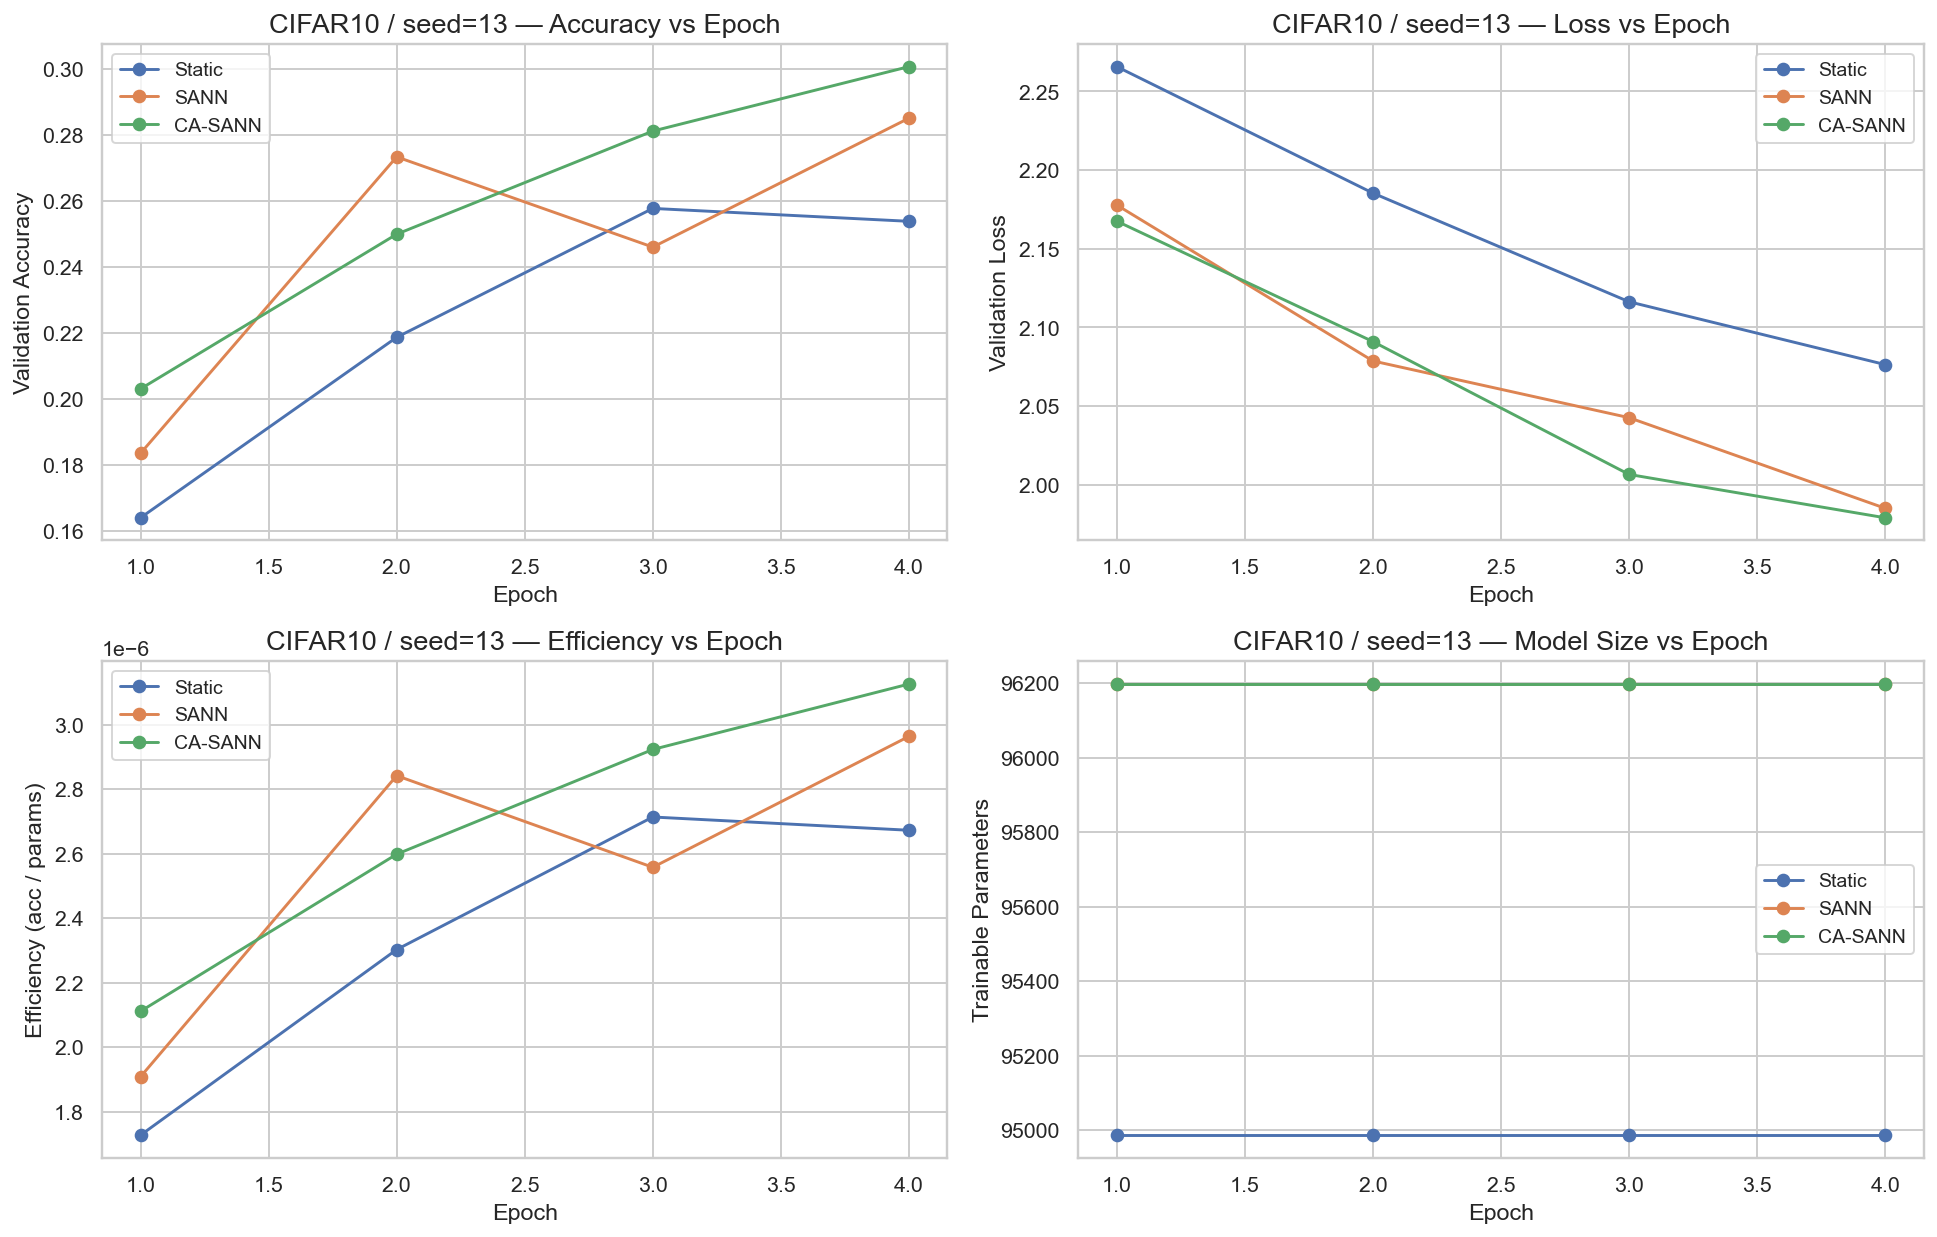

In [6]:
def load_result_payload(run_dir: Path, dataset: str, seed: int, model: str) -> dict:
    path = run_dir / dataset / f'seed_{seed}' / model / 'result.json'
    if not path.exists():
        raise FileNotFoundError(f'Missing: {path}')
    return load_json(path)

def time_series_df(payload: dict) -> pd.DataFrame:
    ts = payload.get('time_series', {})
    df = pd.DataFrame(ts)
    # ensure epoch exists
    if 'epoch' in df.columns:
        df['epoch'] = df['epoch'].astype(int)
    return df

def plot_metrics(payloads: dict[str, dict], title_prefix: str = '') -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=140)
    axes = axes.ravel()

    for label, payload in payloads.items():
        df = time_series_df(payload)
        if df.empty:
            continue
        axes[0].plot(df['epoch'], df.get('val_accuracy', np.nan), marker='o', label=label)
        axes[1].plot(df['epoch'], df.get('val_loss', np.nan), marker='o', label=label)
        axes[2].plot(df['epoch'], df.get('efficiency', np.nan), marker='o', label=label)
        axes[3].plot(df['epoch'], df.get('model_size', np.nan), marker='o', label=label)

    axes[0].set_title(f'{title_prefix}Accuracy vs Epoch'.strip())
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Accuracy')
    axes[0].legend()

    axes[1].set_title(f'{title_prefix}Loss vs Epoch'.strip())
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Loss')
    axes[1].legend()

    axes[2].set_title(f'{title_prefix}Efficiency vs Epoch'.strip())
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Efficiency (acc / params)')
    axes[2].legend()

    axes[3].set_title(f'{title_prefix}Model Size vs Epoch'.strip())
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('Trainable Parameters')
    axes[3].legend()

    fig.tight_layout()
    plt.show()

# Choose dataset/seed to visualize
DATASET = 'cifar10'
SEED = 13
MODELS = ['Static', 'SANN', 'CA-SANN']

payloads = {}
for m in MODELS:
    try:
        payloads[m] = load_result_payload(RUN_DIR, DATASET, SEED, m)
    except FileNotFoundError:
        pass

print('Loaded models:', list(payloads.keys()))
plot_metrics(payloads, title_prefix=f'{DATASET.upper()} / seed={SEED} — ')

---
## SECTION 3B: INTERACTIVE EXPLORER (ipywidgets)

Use the controls to:
- Select **model** (Static / SANN / CA-SANN)
- Select **epoch** (slider)
- Toggle **growth event markers** and **efficiency curve**

The plot updates live for better understanding and presentation.

In [ ]:
from __future__ import annotations

def _available_models() -> list[str]:
    if 'payloads' in globals() and isinstance(payloads, dict) and payloads:
        models = list(payloads.keys())
    elif 'df_runs' in globals() and df_runs is not None and not getattr(df_runs, 'empty', True):
        d = df_runs.copy()
        d = d[(d['dataset'].astype(str).str.lower() == DATASET.lower()) & (d['seed'].astype(int) == int(SEED))]
        models = sorted(d['model'].astype(str).unique().tolist())
    else:
        models = ['Static', 'SANN', 'CA-SANN']
    order = ['Static', 'SANN', 'CA-SANN']
    return [m for m in order if m in models] + [m for m in models if m not in order]

def _load_payload(model: str) -> dict:
    if 'payloads' in globals() and isinstance(payloads, dict) and model in payloads:
        return payloads[model]
    return load_result_payload(RUN_DIR, DATASET, SEED, model)

def _ts_df(payload: dict) -> pd.DataFrame:
    df = time_series_df(payload).copy()
    if df.empty:
        return df
    if 'epoch' in df.columns:
        df['epoch'] = df['epoch'].astype(int)
        df = df.sort_values('epoch')
    return df.reset_index(drop=True)

def _event_epochs(df: pd.DataFrame, col: str) -> list[int]:
    if df.empty or 'epoch' not in df.columns or col not in df.columns:
        return []
    vals = df[col].fillna(0).astype(float).to_numpy()
    deltas = np.diff(np.concatenate([[0.0], vals]))
    epochs = df['epoch'].astype(int).to_numpy()
    return [int(e) for e, d in zip(epochs, deltas) if d > 0.0]

def interactive_epoch_viewer() -> None:
    models = _available_models()
    if not models:
        print('No models available for interactive view.')
        return

    model_dropdown = widgets.Dropdown(
        options=models,
        value=models[0],
        description='Model:',
        layout=widgets.Layout(width='240px'),
    )
    epoch_slider = widgets.IntSlider(value=0, min=0, max=1, step=1, description='Epoch:', continuous_update=False)

    show_growth = widgets.ToggleButton(value=True, description='Show growth events')
    show_eff = widgets.ToggleButton(value=True, description='Show efficiency curve')

    out = widgets.Output()

    def _sync_epoch_slider() -> None:
        try:
            df = _ts_df(_load_payload(model_dropdown.value))
        except Exception:
            df = pd.DataFrame()
        if df.empty or 'epoch' not in df.columns:
            epoch_slider.max = 0
            epoch_slider.value = 0
            return
        max_epoch = int(df['epoch'].max())
        epoch_slider.max = max_epoch
        epoch_slider.value = min(int(epoch_slider.value), max_epoch)

    def _render() -> None:
        with out:
            clear_output(wait=True)
            try:
                payload = _load_payload(model_dropdown.value)
                df = _ts_df(payload)
            except Exception as e:
                print('Failed to load payload:', e)
                return

            if df.empty:
                print('No time series available.')
                return

            selected_epoch = int(epoch_slider.value)
            df_upto = df[df['epoch'] <= selected_epoch].copy()
            if df_upto.empty:
                df_upto = df.iloc[:1].copy()

            # closest epoch row (handles gaps)
            idx = (df['epoch'] - selected_epoch).abs().idxmin()
            row = df.loc[idx]
            epoch_actual = int(row['epoch'])

            want_eff = bool(show_eff.value)
            nrows = 3 if want_eff else 2
            fig, axes = plt.subplots(nrows, 1, figsize=(12, 7.5 if want_eff else 5.5), dpi=140, sharex=True)

            ax_acc = axes[0]
            ax_loss = axes[1]
            ax_acc.plot(df_upto['epoch'], df_upto.get('val_accuracy', np.nan), marker='o', label='val_accuracy')
            ax_loss.plot(df_upto['epoch'], df_upto.get('val_loss', np.nan), marker='o', label='val_loss')

            for ax in (ax_acc, ax_loss):
                ax.axvline(epoch_actual, color='black', alpha=0.25, linestyle='--', linewidth=2)
                ax.grid(True, alpha=0.25)
                ax.legend(loc='best')

            ax_acc.set_title(f"{DATASET.upper()} / seed={SEED} / {model_dropdown.value} — up to epoch {selected_epoch}")
            ax_acc.set_ylabel('Accuracy')
            ax_loss.set_ylabel('Loss')

            if bool(show_growth.value):
                growth_epochs = _event_epochs(df, 'growth_events')
                rejected_epochs = _event_epochs(df, 'rejected_growth_events')
                explore_epochs = _event_epochs(df, 'exploration_growth_events')
                for ge in growth_epochs:
                    ax_acc.axvline(ge, color='green', alpha=0.25, linewidth=2)
                for re in rejected_epochs:
                    ax_acc.axvline(re, color='red', alpha=0.25, linewidth=2)
                for xe in explore_epochs:
                    ax_acc.axvline(xe, color='orange', alpha=0.25, linewidth=2)

            if want_eff:
                ax_eff = axes[2]
                ax_eff.plot(df_upto['epoch'], df_upto.get('efficiency', np.nan), marker='o', label='efficiency')
                ax_eff.axvline(epoch_actual, color='black', alpha=0.25, linestyle='--', linewidth=2)
                ax_eff.set_ylabel('Efficiency')
                ax_eff.set_xlabel('Epoch')
                ax_eff.grid(True, alpha=0.25)
                ax_eff.legend(loc='best')
            else:
                ax_loss.set_xlabel('Epoch')

            fig.tight_layout()
            plt.show()

            val_acc = float(row.get('val_accuracy', np.nan))
            val_loss = float(row.get('val_loss', np.nan))
            eff = float(row.get('efficiency', np.nan))
            print(f"Snapshot at epoch={epoch_actual}: val_acc={val_acc:.6f} | val_loss={val_loss:.6f} | efficiency={eff:.6e}")

    def _on_change(change=None) -> None:
        _sync_epoch_slider()
        _render()

    for w in (model_dropdown, epoch_slider, show_growth, show_eff):
        w.observe(_on_change, names='value')

    display(widgets.HBox([model_dropdown, epoch_slider, show_growth, show_eff]), out)
    _sync_epoch_slider()
    _render()

# Uses DATASET/SEED from Section 3 (defaults are set there).
interactive_epoch_viewer()

Output()

---
## SECTION 4: MARK GROWTH EVENTS

We mark growth-related events using vertical lines:
- **Growth events** (green)
- **Rejected growth** (red)
- **Exploration growth** (orange)

Event epochs are inferred from cumulative counters in `time_series` by taking per-epoch differences.

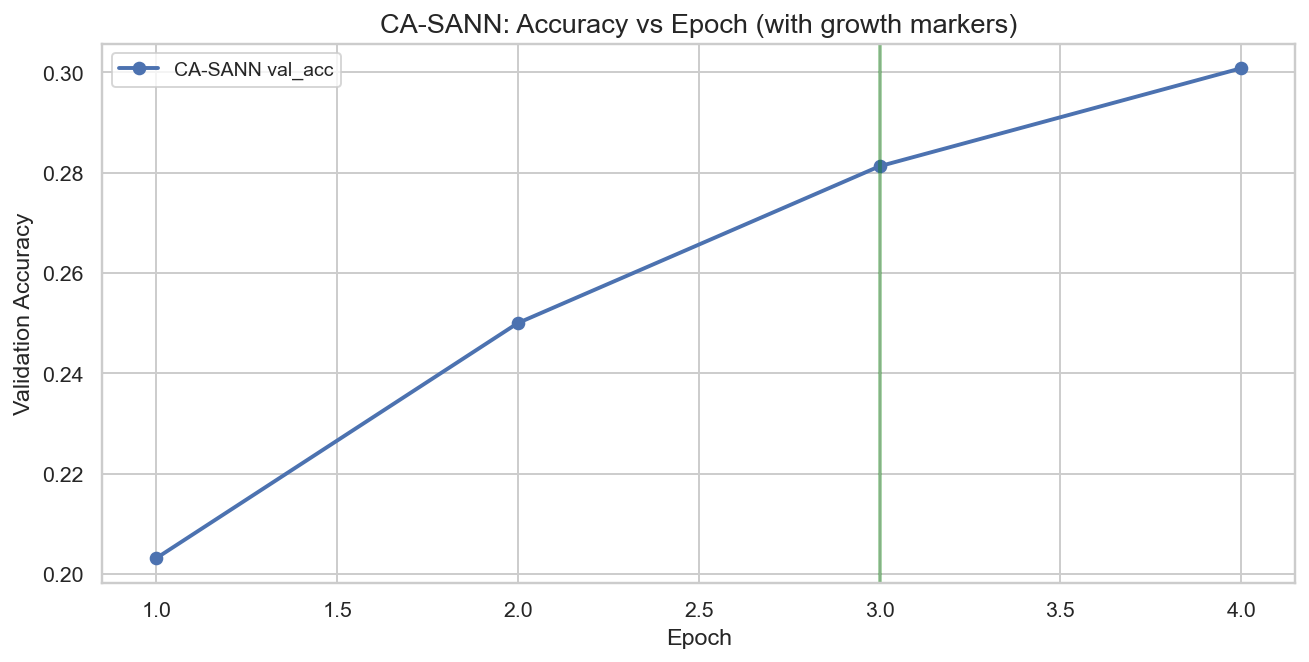

In [11]:
def _event_epochs_from_cumulative(df: pd.DataFrame, col: str) -> list[int]:
    if col not in df.columns or 'epoch' not in df.columns or df.empty:
        return []
    vals = df[col].fillna(0).astype(float).to_numpy()
    deltas = np.diff(np.concatenate([[0.0], vals]))
    epochs = df['epoch'].astype(int).to_numpy()
    return [int(e) for e, d in zip(epochs, deltas) if d > 0.0]

def plot_accuracy_with_growth_markers(payload: dict, label: str) -> None:
    df = time_series_df(payload)
    if df.empty:
        print('No time series available')
        return

    growth_epochs = _event_epochs_from_cumulative(df, 'growth_events')
    rejected_epochs = _event_epochs_from_cumulative(df, 'rejected_growth_events')
    explore_epochs = _event_epochs_from_cumulative(df, 'exploration_growth_events')

    fig, ax = plt.subplots(figsize=(11, 5), dpi=140)
    ax.plot(df['epoch'], df.get('val_accuracy', np.nan), marker='o', linewidth=2, label=f'{label} val_acc')

    for e in growth_epochs:
        ax.axvline(e, color='green', alpha=0.35, linestyle='-', linewidth=2)
    for e in rejected_epochs:
        ax.axvline(e, color='red', alpha=0.35, linestyle='-', linewidth=2)
    for e in explore_epochs:
        ax.axvline(e, color='orange', alpha=0.35, linestyle='-', linewidth=2)

    ax.set_title(f'{label}: Accuracy vs Epoch (with growth markers)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy')
    ax.legend()
    plt.show()

# Example: visualize CA-SANN growth markers if available
if 'CA-SANN' in payloads:
    plot_accuracy_with_growth_markers(payloads['CA-SANN'], 'CA-SANN')
else:
    print('CA-SANN payload not loaded for this RUN_DIR/DATASET/SEED')

In [15]:
# SECTION 4B: GROWTH ANIMATION (matplotlib.animation)

# This animation visually demonstrates network growth over epochs:
# - Left: layer widths (neurons for MLP / channels for CNN) with newly added units highlighted in green
# - Right: validation accuracy and model size curves with a moving epoch marker

from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

import torch

# Choose which model to animate
MODEL_TO_ANIMATE = 'CA-SANN'  # 'Static' | 'SANN' | 'CA-SANN'

def _get_payload_for_model(model: str) -> dict:
    if 'payloads' in globals() and isinstance(payloads, dict) and model in payloads:
        return payloads[model]
    return load_result_payload(RUN_DIR, DATASET, SEED, model)

def _checkpoint_dir(payload: dict, model: str) -> Path:
    fc = payload.get('final_checkpoint')
    if fc:
        p = Path(str(fc).replace('\\', '/'))
        if p.exists():
            return p.parent
    # fallback to the standard run layout
    return RUN_DIR / DATASET / f'seed_{SEED}' / model / 'checkpoints'

def _epoch_from_name(name: str) -> int | None:
    m = re.search(r"epoch(\d+)", name.lower())
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None

def _map_epoch_to_checkpoint(ckpt_dir: Path) -> dict[int, Path]:
    if not ckpt_dir.exists():
        return {}
    mapping: dict[int, Path] = {}
    for p in ckpt_dir.glob('*.pt'):
        e = _epoch_from_name(p.name)
        if e is None:
            continue
        # Prefer '*final*' if multiple for same epoch
        if e not in mapping:
            mapping[e] = p
        else:
            if ('final' in p.name.lower()) and ('final' not in mapping[e].name.lower()):
                mapping[e] = p
    return mapping

def _state_dict_from_checkpoint(p: Path) -> dict:
    ckpt = torch.load(p, map_location='cpu')
    state = ckpt.get('model_state_dict') or ckpt.get('model') or ckpt.get('state_dict')
    if state is None:
        raise KeyError(f'No model state dict found in checkpoint: {p}')
    return state

def _infer_arch_and_sizes_from_state(state: dict) -> tuple[str, list[int]]:
    # CNN checkpoints include keys like 'hidden_layers.0.conv.weight'
    if any('.conv.weight' in k for k in state.keys()):
        sizes: list[int] = []
        idx = 0
        while True:
            key = f'hidden_layers.{idx}.conv.weight'
            if key not in state:
                break
            w = state[key]
            sizes.append(int(w.shape[0]))
            idx += 1
        return 'cnn', sizes

    # MLP checkpoints typically include linear weights
    sizes = []
    idx = 0
    while True:
        key = None
        for cand in (f'hidden_layers.{idx}.linear.weight', f'hidden_layers.{idx}.weight'):
            if cand in state:
                key = cand
                break
        if key is None:
            break
        w = state[key]
        sizes.append(int(w.shape[0]))
        idx += 1
    return 'mlp', sizes

def _sizes_for_epoch(epoch: int, epoch_to_ckpt: dict[int, Path], fallback_sizes: list[int] | None = None) -> tuple[str, list[int]]:
    # Use exact epoch checkpoint if available, else most recent prior checkpoint, else fallback.
    if epoch_to_ckpt:
        if epoch in epoch_to_ckpt:
            state = _state_dict_from_checkpoint(epoch_to_ckpt[epoch])
            return _infer_arch_and_sizes_from_state(state)
        prior = [e for e in epoch_to_ckpt.keys() if e <= epoch]
        if prior:
            e0 = max(prior)
            state = _state_dict_from_checkpoint(epoch_to_ckpt[e0])
            return _infer_arch_and_sizes_from_state(state)
    if fallback_sizes is None:
        return 'unknown', []
    return 'unknown', list(fallback_sizes)

payload_anim = _get_payload_for_model(MODEL_TO_ANIMATE)
df_anim = time_series_df(payload_anim).copy()
if not df_anim.empty and 'epoch' in df_anim.columns:
    df_anim['epoch'] = df_anim['epoch'].astype(int)
    df_anim = df_anim.sort_values('epoch').reset_index(drop=True)

if df_anim.empty:
    print('No time series available for animation.')
else:
    ckpt_dir = _checkpoint_dir(payload_anim, MODEL_TO_ANIMATE)
    epoch_to_ckpt = _map_epoch_to_checkpoint(ckpt_dir)
    if not epoch_to_ckpt:
        print('Warning: no checkpoints found for per-epoch structure. Animation will still show accuracy/size, but structure may not change.')
        print('Expected checkpoints dir:', ckpt_dir.resolve())

    epochs = df_anim['epoch'].astype(int).to_numpy()
    val_acc = df_anim.get('val_accuracy', np.nan).astype(float).to_numpy()
    model_size = df_anim.get('model_size', np.nan).astype(float).to_numpy()

    # Build per-frame structure sizes
    frames: list[dict] = []
    last_sizes: list[int] | None = None
    arch_kind: str | None = None
    for e in epochs:
        kind, sizes = _sizes_for_epoch(int(e), epoch_to_ckpt, fallback_sizes=last_sizes)
        if arch_kind is None and kind != 'unknown':
            arch_kind = kind
        if not sizes and last_sizes is not None:
            sizes = list(last_sizes)
        delta = [0] * len(sizes)
        if last_sizes is not None and len(last_sizes) == len(sizes):
            delta = [max(0, int(s - p)) for s, p in zip(sizes, last_sizes)]
        last_sizes = list(sizes)
        frames.append({'epoch': int(e), 'sizes': sizes, 'delta': delta})

    # Figure layout
    fig = plt.figure(figsize=(12.5, 6.5), dpi=140)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1.0], height_ratios=[1, 1])
    ax_struct = fig.add_subplot(gs[:, 0])
    ax_acc = fig.add_subplot(gs[0, 1])
    ax_size = fig.add_subplot(gs[1, 1])

    # Static right-side curves
    ax_acc.plot(epochs, val_acc, color='#1f77b4', linewidth=2, marker='o', label='val_accuracy')
    acc_marker, = ax_acc.plot([epochs[0]], [val_acc[0]], 'o', color='black', markersize=7)
    acc_vline = ax_acc.axvline(epochs[0], color='black', alpha=0.25, linestyle='--', linewidth=2)
    ax_acc.set_title('Validation Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('val_accuracy')
    ax_acc.set_ylim(0, 1.0)
    ax_acc.grid(True, alpha=0.25)
    ax_acc.legend(loc='best')

    ax_size.plot(epochs, model_size, color='#d62728', linewidth=2, marker='o', label='model_size')
    size_marker, = ax_size.plot([epochs[0]], [model_size[0]], 'o', color='black', markersize=7)
    size_vline = ax_size.axvline(epochs[0], color='black', alpha=0.25, linestyle='--', linewidth=2)
    ax_size.set_title('Model Size (params)')
    ax_size.set_xlabel('Epoch')
    ax_size.set_ylabel('params')
    ax_size.grid(True, alpha=0.25)
    ax_size.legend(loc='best')

    def _draw_structure(sizes: list[int], delta: list[int], epoch: int) -> None:
        ax_struct.clear()
        if not sizes:
            ax_struct.text(0.5, 0.5, 'No structure info (missing checkpoints)', ha='center', va='center', fontsize=12)
            ax_struct.set_axis_off()
            return
        x = np.arange(len(sizes))
        prev = np.array(sizes, dtype=float) - np.array(delta, dtype=float)
        prev = np.maximum(prev, 0.0)
        ax_struct.bar(x, prev, color='#cfcfcf', edgecolor='black', linewidth=1.0, label='existing')
        if any(d > 0 for d in delta):
            ax_struct.bar(x, delta, bottom=prev, color='#2ca02c', edgecolor='black', linewidth=1.0, label='added this epoch')
        for i, s in enumerate(sizes):
            ax_struct.text(i, s + max(sizes) * 0.02, str(int(s)), ha='center', va='bottom', fontsize=10)
            if i < len(delta) and delta[i] > 0:
                ax_struct.text(i, prev[i] + delta[i] / 2, f"+{int(delta[i])}", ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        ax_struct.set_xticks(x)
        ax_struct.set_xticklabels([f'L{i}' for i in range(len(sizes))])
        ylab = 'Channels' if (arch_kind == 'cnn') else 'Neurons'
        ax_struct.set_ylabel(ylab)
        ax_struct.set_title(f"Structure Growth — {MODEL_TO_ANIMATE} ({DATASET.upper()} seed={SEED}) | epoch={epoch}")
        ax_struct.grid(True, axis='y', alpha=0.2)
        ax_struct.legend(loc='upper left')

    def init():
        f0 = frames[0]
        _draw_structure(f0['sizes'], f0['delta'], f0['epoch'])
        return []

    def update(i: int):
        f = frames[i]
        e = int(f['epoch'])
        _draw_structure(f['sizes'], f['delta'], e)

        # Move epoch markers on right-side plots
        idx = int(np.where(epochs == e)[0][0]) if e in epochs else i
        acc_marker.set_data([epochs[idx]], [val_acc[idx]])
        size_marker.set_data([epochs[idx]], [model_size[idx]])
        acc_vline.set_xdata([epochs[idx], epochs[idx]])
        size_vline.set_xdata([epochs[idx], epochs[idx]])
        return []

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    init_func=init,
    interval=900,
    blit=False,
    repeat=True,
)
plt.close(fig)

# Render as JS HTML (no ffmpeg required)
display(HTML(ani.to_jshtml(fps=1)))

---
## SECTION 5: NEURAL NETWORK STRUCTURE VISUALIZATION (NetworkX)

We visualize the architecture as a simplified layered graph.

- **Before growth**: inferred from the base config (`train.make_model(config)`).
- **After growth**: inferred by loading a checkpoint and inspecting the grown model.

For CIFAR-10, the default is a CNN (conv channel sizes). For MNIST/FashionMNIST, the default is an MLP (hidden layer sizes).

Final checkpoint: runs\cifar10_underfit_delayed_acceptance_smoke\cifar10\seed_13\CA-SANN\checkpoints\ca_sann_epoch004_final.pt


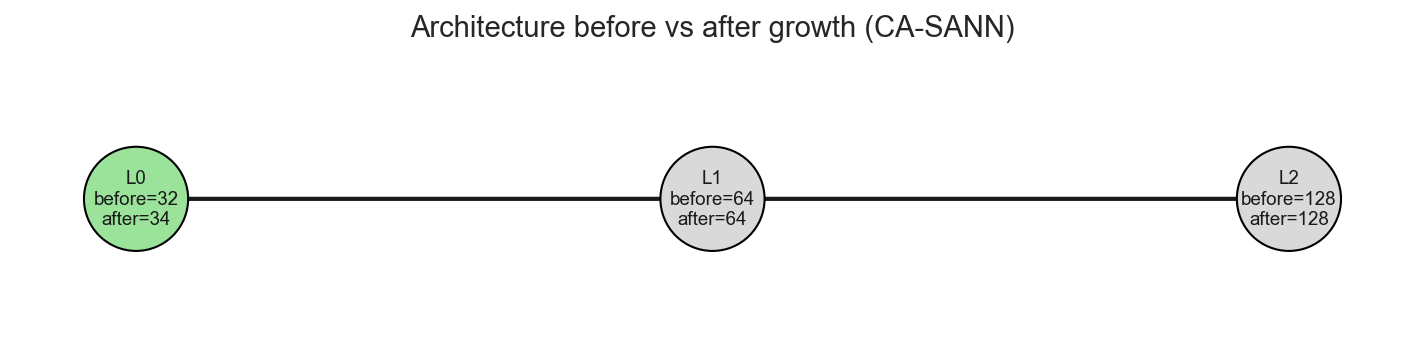

Detected arch: cnn
Before sizes: [32, 64, 128]
After sizes : [34, 64, 128]


In [10]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import torch

from model import DynamicCNN, DynamicCNNConfig, DynamicMLP, DynamicMLPConfig

def _layer_sizes_from_model(model) -> list[int]:
    # Works for DynamicMLP and DynamicCNN in this repo.
    if hasattr(model, 'hidden_dims'):
        return [int(x) for x in model.hidden_dims]
    if hasattr(model, 'hidden_layers'):
        sizes: list[int] = []
        for layer in model.hidden_layers:
            if hasattr(layer, 'out_features'):
                sizes.append(int(layer.out_features))
            elif hasattr(layer, 'out_channels'):
                sizes.append(int(layer.out_channels))
        return sizes
    return []

def build_layer_graph(before: list[int], after: list[int]) -> nx.DiGraph:
    g = nx.DiGraph()
    n_layers = max(len(before), len(after))
    for i in range(n_layers):
        b = before[i] if i < len(before) else None
        a = after[i] if i < len(after) else None
        label = f'L{i}\n'
        if b is not None:
            label += f'before={b}\n'
        if a is not None:
            label += f'after={a}'
        g.add_node(i, label=label, before=b, after=a)
        if i > 0:
            g.add_edge(i - 1, i)
    return g

def draw_layer_graph(g: nx.DiGraph, title: str) -> None:
    pos = {i: (i, 0) for i in g.nodes()}
    labels = {i: g.nodes[i]['label'] for i in g.nodes()}

    colors = []
    for i in g.nodes():
        b = g.nodes[i].get('before')
        a = g.nodes[i].get('after')
        if b is not None and a is not None and a > b:
            colors.append('#9be39b')  # light green if grew
        else:
            colors.append('#d9d9d9')

    plt.figure(figsize=(12, 2.6), dpi=150)
    nx.draw_networkx_nodes(g, pos, node_color=colors, node_size=2500, edgecolors='black', linewidths=1)
    nx.draw_networkx_edges(g, pos, arrows=True, arrowsize=18, width=2)
    nx.draw_networkx_labels(g, pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    plt.show()

def _infer_arch_from_state(state: dict) -> str:
    # CNN checkpoints include keys like 'hidden_layers.0.conv.weight'
    if any('.conv.weight' in k for k in state.keys()):
        return 'cnn'
    return 'mlp'

def _infer_cnn_channels(state: dict) -> list[int]:
    channels: list[int] = []
    idx = 0
    while True:
        key = f'hidden_layers.{idx}.conv.weight'
        if key not in state:
            break
        w = state[key]
        channels.append(int(w.shape[0]))
        idx += 1
    return channels

def _infer_mlp_hidden_dims(state: dict) -> list[int]:
    hidden: list[int] = []
    idx = 0
    while True:
        key = None
        for cand in (f'hidden_layers.{idx}.linear.weight', f'hidden_layers.{idx}.weight'):
            if cand in state:
                key = cand
                break
        if key is None:
            break
        w = state[key]
        hidden.append(int(w.shape[0]))
        idx += 1
    return hidden

def load_checkpoint_model(checkpoint_path: Path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    state = ckpt.get('model_state_dict') or ckpt.get('model') or ckpt.get('state_dict')
    if state is None:
        raise KeyError('No model state dict found in checkpoint')

    arch = _infer_arch_from_state(state)
    if arch == 'cnn':
        channels = _infer_cnn_channels(state)
        w0 = state['hidden_layers.0.conv.weight']
        in_channels = int(w0.shape[1])
        kernel_size = int(w0.shape[2])
        model = DynamicCNN(
            DynamicCNNConfig(
                in_channels=in_channels,
                channels=channels,
                num_classes=10,
                activation='relu',
                kernel_size=kernel_size,
                use_batchnorm=True,
            )
        )
        model.load_state_dict(state, strict=False)
        model.eval()
        return arch, model
    else:
        hidden_dims = _infer_mlp_hidden_dims(state)
        w0 = None
        for cand in ('hidden_layers.0.linear.weight', 'hidden_layers.0.weight'):
            if cand in state:
                w0 = state[cand]
                break
        input_dim = int(w0.shape[1]) if w0 is not None else (28 * 28)
        model = DynamicMLP(
            DynamicMLPConfig(
                input_dim=input_dim,
                hidden_dims=hidden_dims if hidden_dims else [128, 64],
                output_dim=10,
                activation='relu',
            )
        )
        model.load_state_dict(state, strict=False)
        model.eval()
        return arch, model

# Pick a model run and visualize before/after using its final checkpoint
MODEL_FOR_ARCH = 'CA-SANN'
payload_arch = payloads.get(MODEL_FOR_ARCH)
if payload_arch is None:
    print('No payload available for architecture visualization')
else:
    final_ckpt = Path(payload_arch['final_checkpoint'])
    if not final_ckpt.exists():
        final_ckpt = Path(str(final_ckpt).replace('\\', '/'))
    print('Final checkpoint:', final_ckpt)

    arch, model_after = load_checkpoint_model(final_ckpt)

    # Before-growth reference sizes (defaults)
    before_sizes = [32, 64, 128] if arch == 'cnn' else [128, 64]
    after_sizes = _layer_sizes_from_model(model_after)

    g = build_layer_graph(before_sizes, after_sizes)
    draw_layer_graph(g, f'Architecture before vs after growth ({MODEL_FOR_ARCH})')
    print('Detected arch:', arch)
    print('Before sizes:', before_sizes)
    print('After sizes :', after_sizes)

---
## SECTION 6: DECISION FLOW VISUALIZATION (Graphviz)

This diagram shows the CA-SANN decision pipeline:

1. Check `capacity_status`
2. Check `difficulty_score`
3. Growth allowed?
4. Apply growth
5. Delayed evaluation
6. Keep or revert

In [12]:
import shutil

def draw_ca_sann_flow() -> Digraph:
    dot = Digraph('CA_SANN_Flow')
    dot.attr(rankdir='LR', fontsize='12')

    dot.node('start', 'Start epoch')
    dot.node('cap', 'Check capacity_status')
    dot.node('diff', 'Compute difficulty_score')
    dot.node('allow', 'Growth allowed?')
    dot.node('apply', 'Apply growth candidate')
    dot.node('eval0', 'Immediate eval\n(acc/eff change)')
    dot.node('delay', 'Delayed evaluation\n(train 2–3 epochs)')
    dot.node('keep', 'delayed_keep')
    dot.node('revert', 'delayed_reject (revert)')
    dot.node('nogrow', 'No growth')

    dot.edge('start', 'cap')
    dot.edge('cap', 'diff')
    dot.edge('diff', 'allow')

    dot.edge('allow', 'apply', label='yes')
    dot.edge('allow', 'nogrow', label='no')

    dot.edge('apply', 'eval0')
    dot.edge('eval0', 'delay', label='early_growth_underfit\n(if underfit)')
    dot.edge('delay', 'keep', label='acc improves OR eff recovers')
    dot.edge('delay', 'revert', label='otherwise')

    return dot

dot = draw_ca_sann_flow()

# On Windows, the python `graphviz` package still requires Graphviz system binaries (dot.exe).
if shutil.which('dot') is None:
    print("Graphviz executable 'dot' not found on PATH; showing DOT source instead.")
    print(dot.source)
    dot.source
else:
    dot

Graphviz executable 'dot' not found on PATH; showing DOT source instead.
digraph CA_SANN_Flow {
	fontsize=12 rankdir=LR
	start [label="Start epoch"]
	cap [label="Check capacity_status"]
	diff [label="Compute difficulty_score"]
	allow [label="Growth allowed?"]
	apply [label="Apply growth candidate"]
	eval0 [label="Immediate eval
(acc/eff change)"]
	delay [label="Delayed evaluation
(train 2–3 epochs)"]
	keep [label=delayed_keep]
	revert [label="delayed_reject (revert)"]
	nogrow [label="No growth"]
	start -> cap
	cap -> diff
	diff -> allow
	allow -> apply [label=yes]
	allow -> nogrow [label=no]
	apply -> eval0
	eval0 -> delay [label="early_growth_underfit
(if underfit)"]
	delay -> keep [label="acc improves OR eff recovers"]
	delay -> revert [label=otherwise]
}



---
## SECTION 7: COMPARISON BAR CHART

We compare **Static vs SANN vs CA-SANN** using bar charts for:
- Test Accuracy
- Model Size
- Efficiency (accuracy per 100k params)

Data source: `aggregate_results.csv` (preferred) or `seed_results.csv` if aggregate is not available.

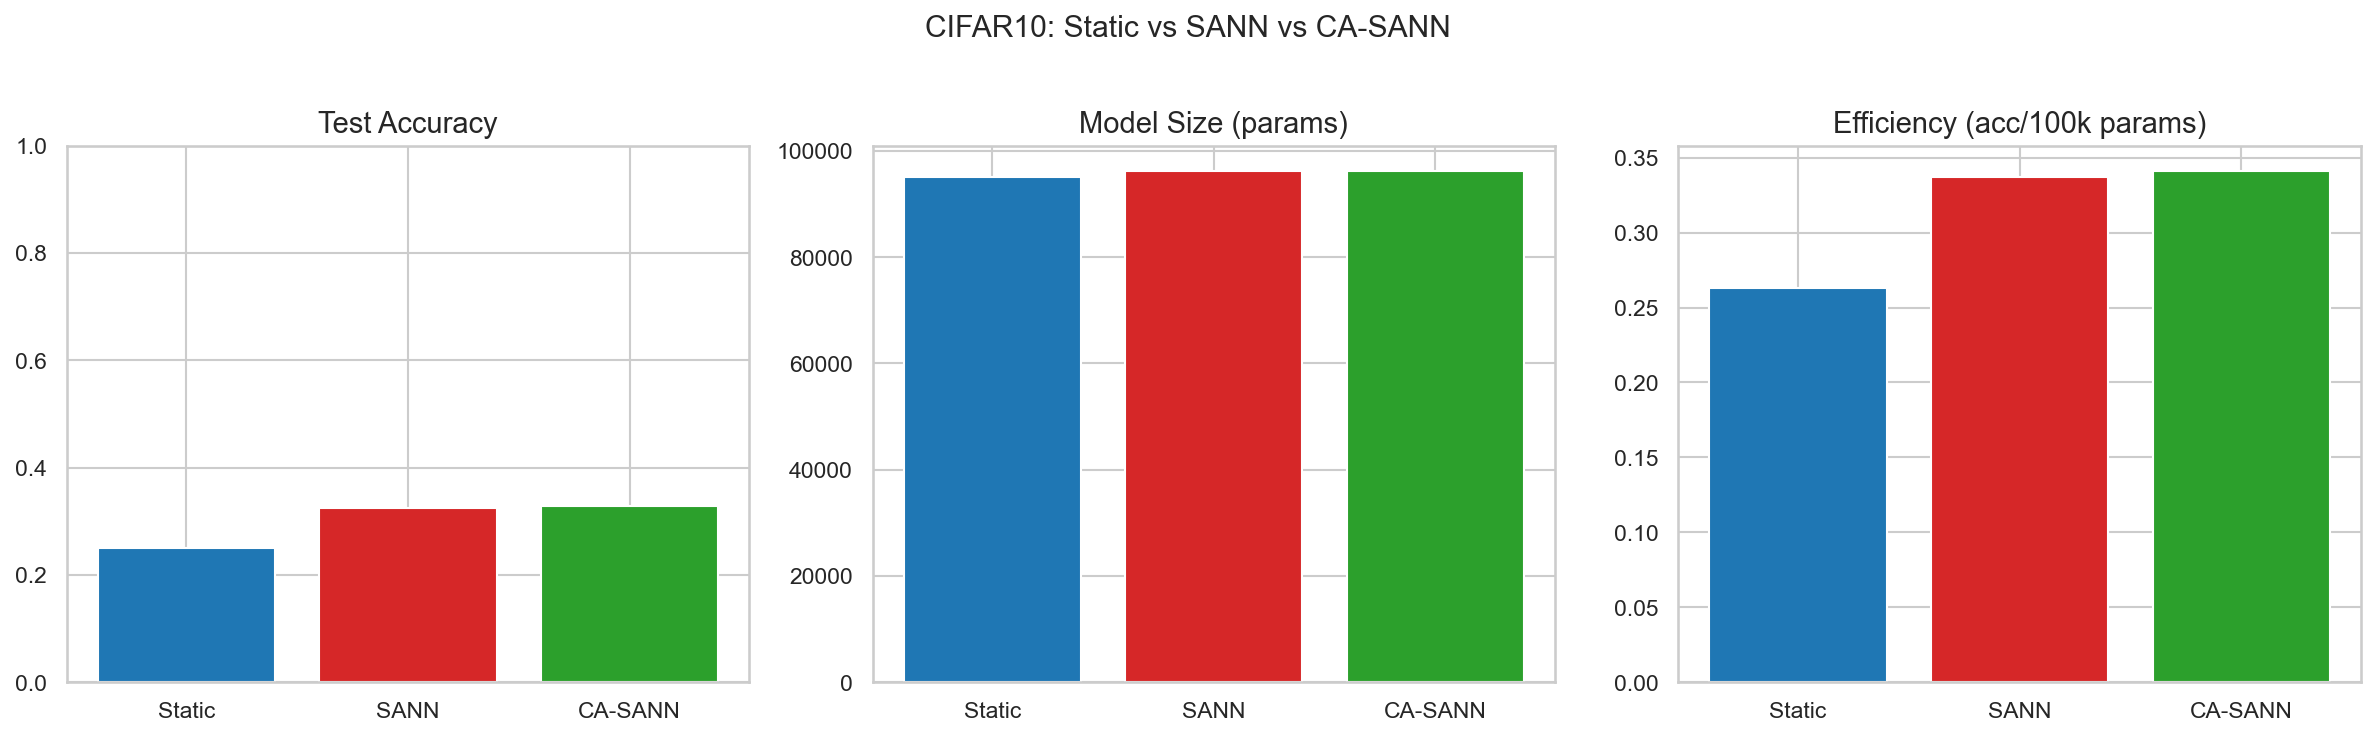

In [13]:
def bar_compare(df: pd.DataFrame, dataset: str) -> None:
    df_d = df[df['dataset'].astype(str).str.lower().str.strip() == dataset.lower().strip()].copy()
    if df_d.empty:
        print('No rows for dataset:', dataset)
        return

    model_order = ['Static', 'SANN', 'CA-SANN']
    df_d['model'] = df_d['model'].astype(str)
    df_d['model'] = pd.Categorical(df_d['model'], categories=model_order, ordered=True)
    df_d = df_d.sort_values('model')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), dpi=150)

    axes[0].bar(df_d['model'].astype(str), df_d['test_accuracy_mean'], color=['#1f77b4', '#d62728', '#2ca02c'])
    axes[0].set_title('Test Accuracy')
    axes[0].set_ylim(0, 1.0)

    axes[1].bar(df_d['model'].astype(str), df_d['model_size_mean'], color=['#1f77b4', '#d62728', '#2ca02c'])
    axes[1].set_title('Model Size (params)')

    axes[2].bar(df_d['model'].astype(str), df_d['accuracy_per_100k_params_mean'], color=['#1f77b4', '#d62728', '#2ca02c'])
    axes[2].set_title('Efficiency (acc/100k params)')

    fig.suptitle(f'{dataset.upper()}: Static vs SANN vs CA-SANN', y=1.02)
    fig.tight_layout()
    plt.show()

if df_agg is not None and not df_agg.empty:
    bar_compare(df_agg, DATASET)
else:
    # Fallback: compute means from seed_results
    if df_seed is None or df_seed.empty:
        print('No aggregate_results.csv or seed_results.csv available.')
    else:
        df_tmp = df_seed.copy()
        df_tmp['test_accuracy_mean'] = df_tmp['test_accuracy']
        df_tmp['model_size_mean'] = df_tmp['model_size']
        df_tmp['accuracy_per_100k_params_mean'] = df_tmp['accuracy_per_100k_params']
        df_group = df_tmp.groupby(['dataset','model'], as_index=False)[['test_accuracy_mean','model_size_mean','accuracy_per_100k_params_mean']].mean()
        bar_compare(df_group, DATASET)

---
## SECTION 8: FINAL INSIGHTS

This section automatically prints:
- Best model by test accuracy
- Efficiency winner (acc/100k params)
- Growth summary (events / rejected / exploration)

In [14]:
def summarize_insights(df_agg: pd.DataFrame | None, df_seed: pd.DataFrame | None, dataset: str) -> None:
    if df_agg is not None and not df_agg.empty:
        df_d = df_agg[df_agg['dataset'].astype(str).str.lower().str.strip() == dataset.lower().strip()].copy()
        if df_d.empty:
            print('No aggregate rows for dataset:', dataset)
            return
        # Best by accuracy
        best_row = df_d.loc[df_d['test_accuracy_mean'].astype(float).idxmax()]
        eff_row = df_d.loc[df_d['accuracy_per_100k_params_mean'].astype(float).idxmax()]

        print('Dataset:', dataset)
        print('Best model (test accuracy):', best_row['model'], 'acc=', float(best_row['test_accuracy_mean']))
        print('Efficiency winner (acc/100k):', eff_row['model'], 'eff=', float(eff_row['accuracy_per_100k_params_mean']))

        # Growth summary for CA-SANN if present
        ca = df_d[df_d['model'].astype(str) == 'CA-SANN']
        if not ca.empty:
            r = ca.iloc[0]
            print('CA-SANN growth summary:')
            print('  growth_events_mean:', float(r.get('growth_events_mean', 0.0)))
            print('  candidate_growth_events_mean:', float(r.get('candidate_growth_events_mean', 0.0)))
            print('  exploration_growth_events_mean:', float(r.get('exploration_growth_events_mean', 0.0)))
            print('  rejected_growth_events_mean:', float(r.get('rejected_growth_events_mean', 0.0)))
        return

    if df_seed is None or df_seed.empty:
        print('No data available for insights.')
        return

    df_d = df_seed[df_seed['dataset'].astype(str).str.lower().str.strip() == dataset.lower().strip()].copy()
    if df_d.empty:
        print('No seed rows for dataset:', dataset)
        return

    # Best by accuracy over all seeds (mean)
    df_m = df_d.groupby('model', as_index=False).agg({
        'test_accuracy': 'mean',
        'accuracy_per_100k_params': 'mean',
        'growth_events': 'mean',
        'candidate_growth_events': 'mean',
        'exploration_growth_events': 'mean',
        'rejected_growth_events': 'mean',
    })
    best_row = df_m.loc[df_m['test_accuracy'].astype(float).idxmax()]
    eff_row = df_m.loc[df_m['accuracy_per_100k_params'].astype(float).idxmax()]

    print('Dataset:', dataset)
    print('Best model (test accuracy):', best_row['model'], 'acc=', float(best_row['test_accuracy']))
    print('Efficiency winner (acc/100k):', eff_row['model'], 'eff=', float(eff_row['accuracy_per_100k_params']))

    ca = df_m[df_m['model'].astype(str) == 'CA-SANN']
    if not ca.empty:
        r = ca.iloc[0]
        print('CA-SANN growth summary:')
        print('  growth_events_mean:', float(r.get('growth_events', 0.0)))
        print('  candidate_growth_events_mean:', float(r.get('candidate_growth_events', 0.0)))
        print('  exploration_growth_events_mean:', float(r.get('exploration_growth_events', 0.0)))
        print('  rejected_growth_events_mean:', float(r.get('rejected_growth_events', 0.0)))

summarize_insights(df_agg, df_seed, DATASET)

Dataset: cifar10
Best model (test accuracy): CA-SANN acc= 0.328125
Efficiency winner (acc/100k): CA-SANN eff= 0.3410933699245306
CA-SANN growth summary:
  growth_events_mean: 1.0
  candidate_growth_events_mean: 1.0
  exploration_growth_events_mean: 0.0
  rejected_growth_events_mean: 0.0
